# Treino CNN Multimodal — versão SEM data leakage (split por `lesion_id`)

**O que mudou em relação ao treino original (resposta à revisão da banca):**

1. **Split agrupado por `lesion_id`** (não por imagem). O HAM10000 tem ~7.470 lesões
   para 10.015 imagens; o split antigo (`train_test_split` por imagem) deixava fotos
   da mesma lesão em treino e teste → *data leakage*. Aqui usamos `GroupShuffleSplit`
   garantindo que **nenhuma lesão** apareça em mais de um conjunto.
2. **Um único split** treino/val/teste é usado tanto pela CNN quanto pelos
   classificadores clássicos. O notebook **exporta os embeddings** (fused 256-d e
   GAP 1536-d) do teste **realmente** held-out, eliminando o segundo leakage
   (antes a CNN e o XGBoost usavam splits diferentes).
3. Avaliação final reportada sobre o **conjunto de teste** (não o de validação).

**Saídas salvas no Drive:** modelo `.keras`, embeddings `.npy` (train/val/test:
fused, gap, clínico, rótulos, `lesion_id`) e um `split_manifest.json` com a prova
de ausência de leakage. Baixe os `.npy` para `data/embeddings_cache/` no repo para
rodar os experimentos clássicos (XGBoost/SMOTE/CV/threshold/bootstrap) na CPU.


In [2]:
# Colab ja tem TF/Keras/sklearn. Instalamos o resto silenciosamente.
!pip -q install albumentations opencv-python-headless kagglehub xgboost imbalanced-learn

In [3]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
import cv2
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from keras import backend as K
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

IMG_SIZE  = (320, 320)
BATCH_SIZE = 32
AUTOTUNE  = tf.data.AUTOTUNE
SEED      = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Augmentation (identico ao treino original) — aplicado so no treino
transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE[0], IMG_SIZE[1]), scale=(0.70, 1.00), ratio=(0.9, 1.1), p=0.6),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=25,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),
], p=1.0)

def augment_image_np(image_np):
    return transform(image=image_np)['image'].astype(np.float32)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_724/2921561814.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),


In [5]:
def find_image_path(image_id, img_dirs, exts=('.jpg','.JPG','.jpeg','.png')):
    for d in img_dirs:
        for ext in exts:
            p = d / f"{image_id}{ext}"
            if p.exists():
                return str(p)
    return None

def categorical_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.-K.epsilon())
        ce = -y_true * tf.math.log(y_pred)
        mod = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(alpha * mod * ce, axis=-1)
    return loss_fixed

def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape, name="img_input")
    base = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=inp)
    base.trainable = False
    x = base.output
    x = layers.GlobalAveragePooling2D(name="image_gap")(x)   # 1536-d (ablacao image-only)
    x = layers.Dense(128, activation="relu", name="image_dense")(x)
    x = layers.Dropout(0.50)(x)
    return inp, x

def build_clinical_branch(n_features):
    inp = layers.Input(shape=(n_features,), name="clin_input")
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(8, activation="relu", name="clin_embed")(x)
    return inp, x

def make_dataset(paths, clin, labels_enc, shuffle=False, augment=False):
    paths = [os.fspath(p) for p in paths]
    clin  = np.asarray(clin, dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, clin, labels_enc))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    def _load(path, c, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE) / 255.0
        return (img, c), tf.one_hot(label, NUM_CLASSES)
    def _aug(inputs, label):
        img, c = inputs
        aug = tf.numpy_function(augment_image_np, [tf.cast(img*255.0, tf.uint8)], tf.float32)
        aug.set_shape(IMG_SIZE + (3,))
        return (aug/255.0, c), label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_aug, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [6]:
# Download via kagglehub (Colab) — usa o caminho RETORNADO (corrige o
# hardcode /kaggle/input que quebrava no Colab).
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
DATA_DIR = Path(path)
print("Dataset em:", DATA_DIR)

meta_csv = next(DATA_DIR.rglob("HAM10000_metadata.csv"))
meta = pd.read_csv(meta_csv)
img_dirs = sorted({p.parent for p in DATA_DIR.rglob("*.jpg")})
print("Pastas de imagem:", img_dirs)
print("Linhas no metadata:", len(meta))
assert "lesion_id" in meta.columns, "lesion_id ausente — split agrupado impossivel!"

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset em: /kaggle/input/skin-cancer-mnist-ham10000
Pastas de imagem: [PosixPath('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1'), PosixPath('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'), PosixPath('/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1'), PosixPath('/kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2')]
Linhas no metadata: 10015


In [7]:
# Pre-processamento clinico (fiel ao treino original; mudamos SO o split).
meta['image_path'] = meta['image_id'].apply(lambda x: find_image_path(x, img_dirs))
meta = meta[meta['image_path'].notna()].reset_index(drop=True)
meta = meta[meta['sex'] != 'unknown'].copy().reset_index(drop=True)  # igual ao original

# age: imputa mediana + z-score
meta['age'] = meta['age'].replace('unknown', np.nan).astype(float)
meta['age'] = meta['age'].fillna(meta['age'].median())
# sex: male=0, female=1
meta['sex'] = meta['sex'].astype(str).str.lower().map({'male':0,'female':1}).fillna(2).astype(int)
# localization: codigo categorico
meta['localization'] = meta['localization'].astype('category').cat.codes

clin = meta[['age','sex','localization']].copy().astype(float)
if clin['age'].std() > 0:
    clin['age'] = (clin['age'] - clin['age'].mean()) / clin['age'].std()
CLIN = clin.values.astype(np.float32)
print("N apos preproc:", len(meta), "| imagens unicas:", meta['image_id'].nunique(),
      "| lesoes unicas:", meta['lesion_id'].nunique())

N apos preproc: 9958 | imagens unicas: 9958 | lesoes unicas: 7420


## A correção: split agrupado por `lesion_id`

Split em **70% treino / 10% validação / 20% teste**, agrupando por lesão.
A validação serve só ao *early stopping* da CNN; os classificadores clássicos a
jusante usam treino∪val (80%) para treinar e o teste (20%) para avaliar — exatamente
o *holdout 80/20* reportado no artigo, agora sem leakage. A célula abaixo **prova**
que nenhuma lesão é compartilhada entre os conjuntos.

In [8]:
groups = meta['lesion_id'].values
y_dx   = meta['dx'].values

# 1) 80% trainval / 20% teste — agrupado por lesao
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(meta, y_dx, groups))

# 2) dentro do trainval: 12,5% para validacao (= 10% do total)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED)
tr_rel, val_rel = next(gss2.split(meta.iloc[trainval_idx], y_dx[trainval_idx], groups[trainval_idx]))
train_idx = trainval_idx[tr_rel]
val_idx   = trainval_idx[val_rel]

# --- PROVA DE AUSENCIA DE LEAKAGE ---
s_tr, s_va, s_te = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (s_tr & s_te), "LEAKAGE treino/teste!"
assert not (s_tr & s_va), "LEAKAGE treino/val!"
assert not (s_va & s_te), "LEAKAGE val/teste!"
print("OK — nenhuma lesao compartilhada entre treino/val/teste.")
print(f"Treino: {len(train_idx)} imgs / {len(s_tr)} lesoes")
print(f"Val   : {len(val_idx)} imgs / {len(s_va)} lesoes")
print(f"Teste : {len(test_idx)} imgs / {len(s_te)} lesoes")

# distribuicao de classes por conjunto (GroupShuffleSplit nao estratifica — conferir)
dist = pd.DataFrame({
    'treino': meta.iloc[train_idx]['dx'].value_counts(),
    'val'   : meta.iloc[val_idx]['dx'].value_counts(),
    'teste' : meta.iloc[test_idx]['dx'].value_counts(),
}).fillna(0).astype(int)
print(dist)

OK — nenhuma lesao compartilhada entre treino/val/teste.
Treino: 7006 imgs / 5194 lesoes
Val   : 979 imgs / 742 lesoes
Teste : 1973 imgs / 1484 lesoes
       treino  val  teste
dx                       
akiec     210   38     79
bcc       374   49     91
bkl       760  119    210
df         91    4     20
mel       806   95    212
nv       4675  658   1325
vasc       90   16     36


In [9]:
le = LabelEncoder().fit(meta['dx'].values)
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)

def split_arrays(idx):
    return (meta.iloc[idx]['image_path'].values,
            CLIN[idx],
            le.transform(meta.iloc[idx]['dx'].values),
            meta.iloc[idx]['lesion_id'].values)

Ximg_tr, Xclin_tr, y_tr, les_tr = split_arrays(train_idx)
Ximg_va, Xclin_va, y_va, les_va = split_arrays(val_idx)
Ximg_te, Xclin_te, y_te, les_te = split_arrays(test_idx)

train_ds = make_dataset(Ximg_tr, Xclin_tr, y_tr, shuffle=True,  augment=True)
val_ds   = make_dataset(Ximg_va, Xclin_va, y_va, shuffle=False, augment=False)
test_ds  = make_dataset(Ximg_te, Xclin_te, y_te, shuffle=False, augment=False)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [10]:
image_in, image_feat = build_image_branch(IMG_SIZE + (3,))
clin_in,  clin_feat  = build_clinical_branch(Xclin_tr.shape[1])
combined = layers.concatenate([image_feat, clin_feat])

z = layers.Dense(256, activation="relu", name="fused_dense_1")(combined)
z = layers.BatchNormalization(name="fused_bn_1")(z)
z = layers.Dropout(0.5, name="fused_dropout_1")(z)
z = layers.Dense(128, activation="relu", name="fused_dense_2")(z)
z = layers.Dropout(0.3, name="fused_dropout_2")(z)
out = layers.Dense(NUM_CLASSES, activation="softmax", name="output_layer")(z)
model = tf.keras.Model(inputs=[image_in, clin_in], outputs=out)
print("Camadas-chave:", [l.name for l in model.layers if l.name in
      ("image_gap","fused_dense_1","output_layer")])

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Camadas-chave: ['image_gap', 'fused_dense_1', 'output_layer']


In [11]:
# === FASE 1: estabilizacao do head (backbone congelado), Focal Loss, LR 1e-4 ===
for layer in model.layers:
    if 'block' in layer.name:
        layer.trainable = False
    elif 'fused' in layer.name or 'input' in layer.name or 'output_layer' in layer.name \
         or 'image_gap' in layer.name or 'image_dense' in layer.name or 'clin' in layer.name:
        layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])

cb1 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('fase1_focal.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cb1)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.1754 - loss: 1.8571
Epoch 1: val_loss improved from None to 0.72420, saving model to fase1_focal.keras

Epoch 1: finished saving model to fase1_focal.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 240s 761ms/step - accuracy: 0.2833 - loss: 1.4257 - val_accuracy: 0.6599 - val_loss: 0.7242 - learning_rate: 1.0000e-04
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.5220 - loss: 0.8070
Epoch 2: val_loss improved from 0.72420 to 0.49873, saving model to fase1_focal.keras

Epoch 2: finished saving model to fase1_focal.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 352ms/step - accuracy: 0.5355 - loss: 0.7785 - val_accuracy: 0.6680 - val_loss: 0.4987 - learning_rate: 1.0000e-04
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.5782 - loss: 0.6997
Epoch 3: val_loss improved from 0.49873 to 0.47765, saving model to fase1_focal.keras

Epoch 3: finished saving model to fase1_focal.keras
219/219 ━━━━━━━━━━━━━━━━━

In [12]:
# === FASE 2: fine-tuning leve do bloco 7, LR 1e-5 ===
model.load_weights('fase1_focal.keras')
trainable = False
for layer in model.layers:
    if 'block7' in layer.name:
        trainable = True
    layer.trainable = trainable or ('fused' in layer.name or 'output_layer' in layer.name
                                    or 'image_dense' in layer.name or 'clin' in layer.name)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('fase2_final.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist2 = model.fit(train_ds, validation_data=val_ds, epochs=35, initial_epoch=25, callbacks=cb2)

Epoch 26/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.6249 - loss: 0.6652
Epoch 26: val_loss improved from None to 0.46212, saving model to fase2_final.keras

Epoch 26: finished saving model to fase2_final.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 202s 634ms/step - accuracy: 0.6272 - loss: 0.6493 - val_accuracy: 0.6721 - val_loss: 0.4621 - learning_rate: 1.0000e-05
Epoch 27/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.6417 - loss: 0.6201
Epoch 27: val_loss improved from 0.46212 to 0.45922, saving model to fase2_final.keras

Epoch 27: finished saving model to fase2_final.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 81s 369ms/step - accuracy: 0.6366 - loss: 0.6201 - val_accuracy: 0.6721 - val_loss: 0.4592 - learning_rate: 1.0000e-05
Epoch 28/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.6252 - loss: 0.6221
Epoch 28: val_loss improved from 0.45922 to 0.45503, saving model to fase2_final.keras

Epoch 28: finished saving model to fase2_final.keras
219/219 ━━━━━━━━

Relatorio (TESTE held-out por lesao):
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        79
         bcc     0.0000    0.0000    0.0000        91
         bkl     0.3483    0.3333    0.3406       210
          df     0.0000    0.0000    0.0000        20
         mel     0.1020    0.0236    0.0383       212
          nv     0.7269    0.9442    0.8214      1325
        vasc     0.0000    0.0000    0.0000        36

    accuracy                         0.6721      1973
   macro avg     0.1682    0.1859    0.1715      1973
weighted avg     0.5362    0.6721    0.5920      1973



<Figure size 800x800 with 0 Axes>

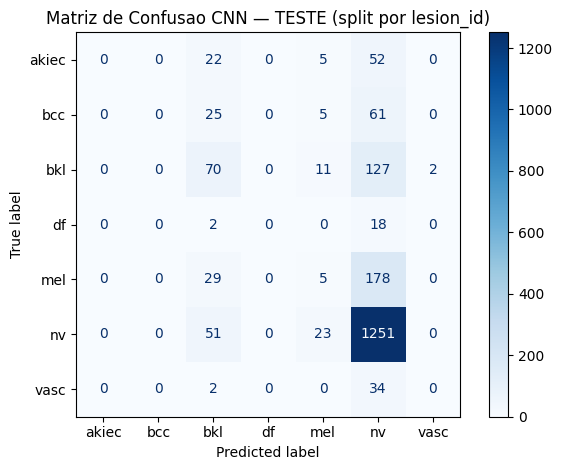

In [13]:
# === Avaliacao final no CONJUNTO DE TESTE (held-out, sem leakage) ===
try:    model.load_weights('fase2_final.keras')
except: model.load_weights('fase1_focal.keras')

y_true, y_pred = [], []
for (Xb, Cb), yb in test_ds:
    p = model.predict([Xb, Cb], verbose=0)
    y_true.extend(np.argmax(yb.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("Relatorio (TESTE held-out por lesao):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusao CNN — TESTE (split por lesion_id)')
plt.tight_layout(); plt.savefig('matrix_cnn_grouped.png', dpi=150); plt.show()

## Extração dos embeddings limpos

Extraímos do **mesmo modelo e mesmo split** os vetores que alimentam os
classificadores clássicos. Como o teste foi held-out por lesão, não há leakage.
- `fused` (256-d): camada `fused_dense_1` — pipeline híbrido principal.
- `gap` (1536-d): camada `image_gap` — *ablation* image-only (sem metadados).
- `clin` (3-d): features clínicas cruas — *ablation* clinical-only.

In [14]:
extr_fused = tf.keras.Model(model.inputs, model.get_layer("fused_dense_1").output)
extr_gap   = tf.keras.Model(model.inputs, model.get_layer("image_gap").output)

def extract(paths, clin, labels_enc):
    ds = make_dataset(paths, clin, labels_enc, shuffle=False, augment=False)
    f = extr_fused.predict(ds, verbose=1)
    g = extr_gap.predict(ds, verbose=1)
    return f, g

f_tr, g_tr = extract(Ximg_tr, Xclin_tr, y_tr)
f_va, g_va = extract(Ximg_va, Xclin_va, y_va)
f_te, g_te = extract(Ximg_te, Xclin_te, y_te)
print("fused:", f_tr.shape, f_te.shape, "| gap:", g_tr.shape, g_te.shape)

219/219 ━━━━━━━━━━━━━━━━━━━━ 68s 257ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 469ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 445ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 314ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 332ms/step
fused: (7006, 256) (1973, 256) | gap: (7006, 1536) (1973, 1536)


In [15]:
from google.colab import drive
drive.mount('/content/drive')
OUT = Path('/content/drive/MyDrive/ICV_retreino_grouped')
OUT.mkdir(parents=True, exist_ok=True)

# Modelo
model.save(OUT / 'modelo_multimodal_final_grouped.keras')

# Embeddings + rotulos + lesion_id (train, val, test)
def save_split(tag, f, g, clin, y, les):
    np.save(OUT / f'X_{tag}_fused.npy', f)
    np.save(OUT / f'X_{tag}_gap.npy',   g)
    np.save(OUT / f'X_{tag}_clin.npy',  np.asarray(clin, dtype=np.float32))
    np.save(OUT / f'y_{tag}.npy',       np.asarray(y))
    np.save(OUT / f'lesion_{tag}.npy',  np.asarray(les))
save_split('train', f_tr, g_tr, Xclin_tr, y_tr, les_tr)
save_split('val',   f_va, g_va, Xclin_va, y_va, les_va)
save_split('test',  f_te, g_te, Xclin_te, y_te, les_te)

# Manifesto com prova de ausencia de leakage e distribuicao
manifest = {
    "classes": CLASS_NAMES,
    "split": {"train": int(len(train_idx)), "val": int(len(val_idx)), "test": int(len(test_idx))},
    "lesoes": {"train": int(len(s_tr)), "val": int(len(s_va)), "test": int(len(s_te))},
    "leakage_check": {"train_test": len(s_tr & s_te), "train_val": len(s_tr & s_va), "val_test": len(s_va & s_te)},
    "dist_teste": meta.iloc[test_idx]['dx'].value_counts().to_dict(),
    "split_method": "GroupShuffleSplit por lesion_id (70/10/20), random_state=42",
}
(OUT / 'split_manifest.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
plt.savefig(OUT / 'matrix_cnn_grouped.png', dpi=150)
print("Salvo em:", OUT)
print(json.dumps(manifest, indent=2, ensure_ascii=False))

Mounted at /content/drive
Salvo em: /content/drive/MyDrive/ICV_retreino_grouped
{
  "classes": [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
  ],
  "split": {
    "train": 7006,
    "val": 979,
    "test": 1973
  },
  "lesoes": {
    "train": 5194,
    "val": 742,
    "test": 1484
  },
  "leakage_check": {
    "train_test": 0,
    "train_val": 0,
    "val_test": 0
  },
  "dist_teste": {
    "nv": 1325,
    "mel": 212,
    "bkl": 210,
    "bcc": 91,
    "akiec": 79,
    "vasc": 36,
    "df": 20
  },
  "split_method": "GroupShuffleSplit por lesion_id (70/10/20), random_state=42"
}


<Figure size 640x480 with 0 Axes>

## Próximos passos (após rodar este notebook)

1. Baixe do Drive (`ICV_retreino_grouped/`) os arquivos `X_*_fused.npy`, `X_*_gap.npy`,
   `X_*_clin.npy`, `y_*.npy`, `lesion_*.npy` e o `split_manifest.json`.
2. Coloque os `.npy` em `data/embeddings_cache/` no repositório (pode sobrescrever os
   antigos — eram do pipeline com leakage).
3. Me avise: eu rodo localmente (CPU) os experimentos clássicos já corrigidos —
   XGBoost/RF/SVM/NB + SMOTE + **StratifiedGroupKFold** (usando `lesion_*`) +
   varredura de limiar + bootstrap + **ablação** (fused vs gap vs clin) — e gero as
   tabelas/figuras limpas para o artigo.
4. Confira no `split_manifest.json` que `leakage_check` está todo zerado (prova p/ a banca).


In [17]:
extr_gap = tf.keras.Model(model.inputs, model.get_layer("image_gap").output)
for tag,(p,c,y) in {'train':(Ximg_tr,Xclin_tr,y_tr),'test':(Ximg_te,Xclin_te,y_te)}.items():
    ds = make_dataset(p, c, y, shuffle=False, augment=False)
    np.save(OUT / f'X_{tag}_gap.npy', extr_gap.predict(ds, verbose=1))
    print(tag, "gap salvo")

219/219 ━━━━━━━━━━━━━━━━━━━━ 73s 268ms/step
train gap salvo
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step
test gap salvo
